For unsupervised machine learning in Python, the most commonly used package is scikit-learn (sklearn). Here are a few key algorithms it provides for unsupervised learning:

📌 Clustering Algorithms
K-Means: sklearn.cluster.KMeans
DBSCAN: sklearn.cluster.DBSCAN
Agglomerative Clustering: sklearn.cluster.AgglomerativeClustering
Mean Shift: sklearn.cluster.MeanShift
Spectral Clustering: sklearn.cluster.SpectralClustering


📌 Dimensionality Reduction
Principal Component Analysis (PCA): sklearn.decomposition.PCA
t-SNE (t-Distributed Stochastic Neighbor Embedding): sklearn.manifold.TSNE
UMAP (from umap-learn package): umap.UMAP()


📌 Anomaly Detection
Isolation Forest: sklearn.ensemble.IsolationForest
One-Class SVM: sklearn.svm.OneClassSVM
LOF (Local Outlier Factor): sklearn.neighbors.LocalOutlierFactor


📌 Other Useful Libraries
SciPy (scipy.cluster.hierarchy) → For hierarchical clustering
HDBSCAN (hdbscan) → More advanced clustering than DBSCAN
To install the necessary packages if you haven't already:

bash
Copy
Edit
pip install scikit-learn umap-learn hdbscan
Would you like help implementing a specific algorithm? 🚀

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import yfinance as yf
import requests
from bs4 import BeautifulSoup
import os
from yfinance import ticker
import concurrent.futures


In [2]:
def get_sp500_tickers():
    """Fetch the list of S&P 500 tickers from Wikipedia."""
    url = 'https://en.wikipedia.org/wiki/List_of_S%26P_500_companies'
    response = requests.get(url)
    soup = BeautifulSoup(response.text, 'html.parser')
    table = soup.find('table', {'id': 'constituents'})
    tickers = []
    for row in table.findAll('tr')[1:]:
        ticker = row.findAll('td')[0].text.strip()
        tickers.append(ticker)
    return tickers

In [16]:
tickers = get_sp500_tickers()

In [ ]:
def fetch_stock_data(ticker):
    try:
        ticker_obj = yf.Ticker(str(ticker))
        return ticker_obj.info
        
    except Exception as e:
        print(f"Error fetching data for {ticker}: {e}")
        return None
    

In [27]:
def fetch_and_download_all_stocks(tickers):
    df = yf.download(tickers, period = '5d', interval = '1d', actions = True, rounding = True, group_by = 'ticker')
    df.to_csv('sp500_data.csv')
    print(df.head())
    return None


In [28]:
fetch_and_download_all_stocks(tickers)

[*********************100%***********************]  503 of 503 completed

4 Failed downloads:
['ETR', 'BF.B', 'LEN']: YFPricesMissingError('$%ticker%: possibly delisted; no price data found  (period=5d)')
['BRK.B']: YFPricesMissingError('$%ticker%: possibly delisted; no price data found  (period=5d) (Yahoo error = "No data found, symbol may be delisted")')


Ticker        CRWD                                                          \
Price         Open    High     Low   Close   Volume Dividends Stock Splits   
Date                                                                         
2025-02-10  424.77  431.90  424.48  428.92  2258800       0.0          0.0   
2025-02-11  426.65  434.78  424.08  431.64  2323800       0.0          0.0   
2025-02-12  425.20  437.60  424.21  434.63  2011000       0.0          0.0   
2025-02-13  435.00  454.13  432.20  453.77  3681300       0.0          0.0   
2025-02-14  449.47  453.46  442.87  451.74  2842500       0.0          0.0   

Ticker        CCI                ...      CAT                            LHX  \
Price        Open   High    Low  ...   Volume Dividends Stock Splits    Open   
Date                             ...                                           
2025-02-10  89.80  90.07  88.70  ...  1944400       0.0          0.0  206.00   
2025-02-11  89.42  91.31  89.38  ...  1516900       0.0

In [ ]:
data = pd.read_csv('sp500_data.csv')
data


#stock_data = fetch_all_stocks(tickers)


,Ticker,CRWD,CRWD.1,CRWD.2,CRWD.3,CRWD.4,CRWD.5,CRWD.6,CCI,CCI.1,...,CAT.4,CAT.5,CAT.6,LHX,LHX.1,LHX.2,LHX.3,LHX.4,LHX.5,LHX.6
0,Price,Open,High,Low,Close,Volume,Dividends,Stock Splits,Open,High,...,Volume,Dividends,Stock Splits,Open,High,Low,Close,Volume,Dividends,Stock Splits
1,Date,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2025-02-10,424.77,431.9,424.48,428.92,2258800,0.0,0.0,89.8,90.07,...,1944400,0.0,0.0,206.0,209.88,205.27,208.43,1201900,0.0,0.0
3,2025-02-11,426.65,434.78,424.08,431.64,2323800,0.0,0.0,89.42,91.31,...,1516900,0.0,0.0,209.26,209.26,206.17,206.75,1480500,0.0,0.0
4,2025-02-12,425.2,437.6,424.21,434.63,2011000,0.0,0.0,89.73,90.46,...,2833100,0.0,0.0,204.98,204.98,199.56,200.61,1694500,0.0,0.0
5,2025-02-13,435.0,454.13,432.2,453.77,3681300,0.0,0.0,90.06,90.63,...,3547200,0.0,0.0,202.01,204.52,198.43,200.0,2142400,0.0,0.0
6,2025-02-14,449.47,453.46,442.87,451.74,2842500,0.0,0.0,89.28,90.5,...,2043700,0.0,0.0,200.0,201.17,196.67,197.61,1565400,0.0,0.0


In [ ]:
data.T
#Remove Nan date row, get the stock tickers to group nicely, add a row if the stock is increasing or decreasing, integrate data from stock_scores

,0,1,2,3,4,5,6
Ticker,Price,Date,2025-02-10,2025-02-11,2025-02-12,2025-02-13,2025-02-14
CRWD,Open,NaN,424.77,426.65,425.2,435.0,449.47
CRWD.1,High,NaN,431.9,434.78,437.6,454.13,453.46
CRWD.2,Low,NaN,424.48,424.08,424.21,432.2,442.87
CRWD.3,Close,NaN,428.92,431.64,434.63,453.77,451.74
...,...,...,...,...,...,...,...
LHX.2,Low,NaN,205.27,206.17,199.56,198.43,196.67
LHX.3,Close,NaN,208.43,206.75,200.61,200.0,197.61
LHX.4,Volume,NaN,1201900,1480500,1694500,2142400,1565400
LHX.5,Dividends,NaN,0.0,0.0,0.0,0.0,0.0


In [4]:
np.random.seed(42)
X = np.random.rand(100, 2) * 100

In [6]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X) 

In [8]:
k = 3  # Number of clusters
kmeans = KMeans(n_clusters=k, random_state=42)
kmeans.fit(X_scaled)

C:\Users\owenh\anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


KMeans(n_clusters=3, random_state=42)

In [10]:
labels = kmeans.labels_  # Cluster assignments for each point
centroids = kmeans.cluster_centers_

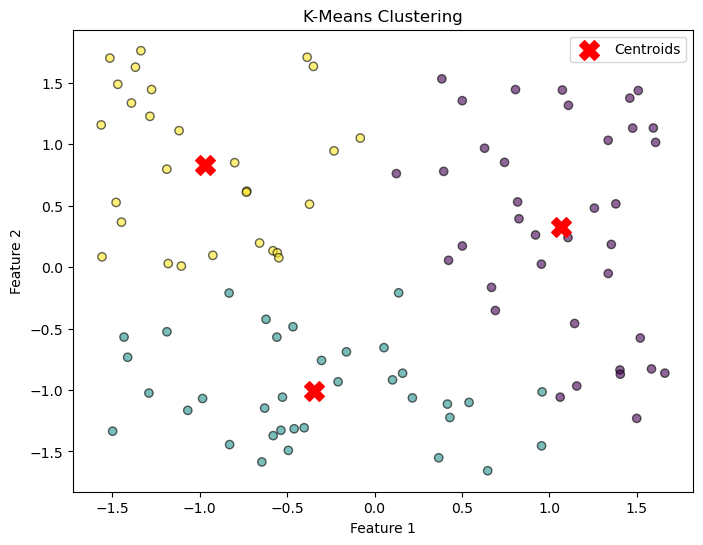

In [12]:
plt.figure(figsize=(8, 6))
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=labels, cmap='viridis', alpha=0.6, edgecolors='k')
plt.scatter(centroids[:, 0], centroids[:, 1], c='red', marker='X', s=200, label='Centroids')
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("K-Means Clustering")
plt.legend()
plt.show()

C:\Users\owenh\anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\owenh\anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\owenh\anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\owenh\anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows wi

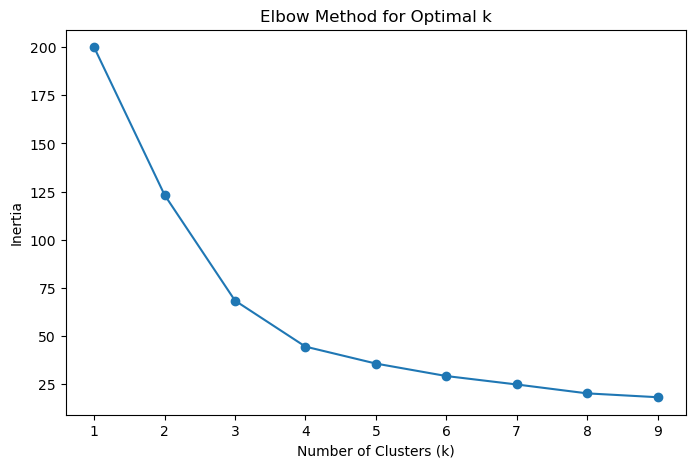

In [14]:
#Find the Optimal k using the Elbow Method (Optional)
inertia = []
K_range = range(1, 10)  # Try different cluster numbers

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)  # Inertia measures clustering quality

plt.figure(figsize=(8, 5))
plt.plot(K_range, inertia, marker='o')
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method for Optimal k")
plt.show()

You'll need stock-related data such as volatility (standard deviation of returns), beta, trading volume, and average return.

If you already have this data in a DataFrame (df), ensure it includes at least these columns:

'volatility' → Standard deviation of daily returns
'beta' → Sensitivity to the market (higher beta = higher risk)
'avg_return' → Mean daily return
'volume' → Average trading volume (optional)

kmeans = KMeans(n_clusters=2, random_state=42)  # 2 clusters: High-Risk & Low-Risk
